# 沐曦 GPU 运行 NV-Generate-MR-Brain 说明文档

[NV-Generate-CTMR](https://github.com/NVIDIA-Medtech/NV-Generate-CTMR) 是 NVIDIA 发布的三维医学影像生成项目。本教程使用其中的 `rflow-mr-brain` 推理入口，从随机噪声生成 synthetic 3D brain MRI image-only NIfTI；模型权重见 [nvidia/NV-Generate-MR-Brain](https://huggingface.co/nvidia/NV-Generate-MR-Brain)。

上游源码依据 [Apache License 2.0](https://www.apache.org/licenses/LICENSE-2.0) 发布，本目录中的 `LICENSE` 为许可证全文。模型权重依据 [NVIDIA Open Model License](https://www.nvidia.com/en-us/agreements/enterprise-software/nvidia-open-model-license/) 发布，权重不随本教程分发。

## 1. 安装

请先在终端完成以下环境与资产准备。

### 1.1 沐曦容器

设备节点、共享目录和镜像名称按目标机器替换；MACA 通过 PyTorch 的 `cuda` 接口使用沐曦 GPU。

```bash
docker run -it --name nv-generate-mr-brain-notebook \
  --device=/dev/mxcd --device=/dev/dri --group-add video \
  --shm-size=16G --security-opt seccomp=unconfined \
  --ulimit memlock=-1 --ulimit stack=67108864 \
  -v /workspace:/workspace \
  <MACA_PYTORCH_IMAGE> /bin/bash
```

### 1.2 依赖、上游源码与模型权重

保留沐曦基础镜像中的 MACA PyTorch，仅为 MONAI 跳过依赖解析，并单独安装其余依赖。下载权重前，请先阅读并接受模型页面的许可证条款。

```bash
python -m pip install --no-deps monai
python -m pip install numpy scipy scikit-image nibabel matplotlib \
  einops huggingface_hub tqdm fire tensorboard PyYAML
python - <<'PY'
import torch
assert torch.cuda.is_available(), "MACA PyTorch 未检测到 GPU"
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))
PY

git clone https://github.com/NVIDIA-Medtech/NV-Generate-CTMR.git \
  /workspace/NV-Generate-CTMR
git -C /workspace/NV-Generate-CTMR checkout \
  61c4ec709b84cad468852243c48e250bec732074
cd /workspace/NV-Generate-CTMR

hf download nvidia/NV-Generate-CT models/autoencoder_v1.pt \
  --revision 75ac080fb1083c403793563477724c038e7d430c --local-dir .
hf download nvidia/NV-Generate-MR-Brain \
  models/diff_unet_3d_rflow-mr-brain_v0.pt \
  --revision 762ddecc59122081d8e04b9fbec9c0deada973f1 --local-dir .
```

## 2. 沐曦 GPU 运行效果显示

### 2.1 运行参数

以下参数是环境检查、配置生成、模型推理、输出校验和可视化的统一入口。默认演示 T1 whole-brain；修改 `MODALITY` 可选择参考 Skill 列举的其他推理分支。

In [1]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

from datetime import datetime
from pathlib import Path
import hashlib
import importlib
import json
import math
import sys
import time

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
import monai

UPSTREAM_ROOT = Path(os.environ.get(
    "NV_GENERATE_MR_BRAIN_ROOT", "/workspace/NV-Generate-CTMR"
)).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ.get(
    "NV_GENERATE_MR_BRAIN_OUTPUT", "/workspace/nv_generate_mr_brain_outputs"
)).expanduser().resolve()
DEVICE = torch.device("cuda:0")

MODALITIES = {
    "mri": 8,
    "mri_t1": 9,
    "mri_t2": 10,
    "mri_flair": 11,
    "mri_swi": 20,
    "mri_t1_skull_stripped": 29,
    "mri_t2_skull_stripped": 30,
    "mri_flair_skull_stripped": 31,
    "mri_swi_skull_stripped": 32,
}
MODALITY = os.environ.get("NV_GENERATE_MR_BRAIN_MODALITY", "mri_t1")
DIM = tuple(json.loads(os.environ.get("NV_GENERATE_MR_BRAIN_DIM", "[256, 256, 256]")))
SPACING = tuple(json.loads(os.environ.get("NV_GENERATE_MR_BRAIN_SPACING", "[1.0, 1.0, 1.0]")))
RANDOM_SEED = int(os.environ.get("NV_GENERATE_MR_BRAIN_SEED", "1234"))
NUM_INFERENCE_STEPS = int(os.environ.get("NV_GENERATE_MR_BRAIN_STEPS", "30"))
CFG_GUIDANCE_SCALE = float(os.environ.get("NV_GENERATE_MR_BRAIN_CFG", "10"))

if MODALITY not in MODALITIES:
    raise ValueError(f"不支持的 MODALITY：{MODALITY}；可选值：{tuple(MODALITIES)}")
if (
    len(DIM) != 3
    or any(type(value) is not int for value in DIM)
    or any(value % 32 for value in DIM)
    or any(value < lower or value > upper for value, lower, upper in zip(DIM, (64, 64, 64), (512, 512, 256)))
):
    raise ValueError(f"DIM 必须为 32 的倍数，且各轴位于 [64, 64, 64] 到 [512, 512, 256]：{DIM}")
if (
    len(SPACING) != 3
    or any(type(value) not in (int, float) for value in SPACING)
    or any(not math.isfinite(float(value)) or value <= 0 for value in SPACING)
):
    raise ValueError(f"SPACING 必须由三个有限正数组成：{SPACING}")
if not 1 <= NUM_INFERENCE_STEPS <= 2000:
    raise ValueError("NUM_INFERENCE_STEPS 必须位于 [1, 2000]")
if not math.isfinite(CFG_GUIDANCE_SCALE) or CFG_GUIDANCE_SCALE < 0:
    raise ValueError("CFG_GUIDANCE_SCALE 必须为有限非负数")

MODEL_DIR = UPSTREAM_ROOT / "models"
AUTOENCODER_PATH = MODEL_DIR / "autoencoder_v1.pt"
DIFFUSION_PATH = MODEL_DIR / "diff_unet_3d_rflow-mr-brain_v0.pt"
BASE_ENV_CONFIG = UPSTREAM_ROOT / "configs/environment_maisi_diff_model_rflow-mr-brain.json"
BASE_MODEL_CONFIG = UPSTREAM_ROOT / "configs/config_maisi_diff_model_rflow-mr-brain.json"
BASE_NETWORK_CONFIG = UPSTREAM_ROOT / "configs/config_network_rflow.json"
MODALITY_MAPPING_PATH = UPSTREAM_ROOT / "configs/modality_mapping.json"
RUN_ID = datetime.now().strftime("%Y%m%d-%H%M%S")
RUN_OUTPUT_DIR = OUTPUT_ROOT / f"{RUN_ID}-{MODALITY}-seed{RANDOM_SEED}"
STAGED_CONFIG_DIR = RUN_OUTPUT_DIR / "_staged_configs"

print("Upstream:", UPSTREAM_ROOT)
print("Device:", DEVICE)
print("Modality:", MODALITY, "| code:", MODALITIES[MODALITY])
print("Supported modalities:", tuple(MODALITIES))
print("Shape (i, j, k):", DIM, "| spacing (mm):", SPACING)
print("Seed:", RANDOM_SEED, "| steps:", NUM_INFERENCE_STEPS, "| CFG:", CFG_GUIDANCE_SCALE)
print("Run output:", RUN_OUTPUT_DIR)

Upstream: /opt/NV-Generate-CTMR
Device: cuda:0
Modality: mri_t1 | code: 9
Supported modalities: ('mri', 'mri_t1', 'mri_t2', 'mri_flair', 'mri_swi', 'mri_t1_skull_stripped', 'mri_t2_skull_stripped', 'mri_flair_skull_stripped', 'mri_swi_skull_stripped')
Shape (i, j, k): (256, 256, 256) | spacing (mm): (1.0, 1.0, 1.0)
Seed: 1234 | steps: 30 | CFG: 10.0
Run output: /workspace/notebook/run-outputs/20260924-040015-mri_t1-seed1234


### 2.2 沐曦 GPU 与资产检查

模型加载前先确认当前 Notebook kernel 能访问沐曦 GPU、上游入口、配置文件和两项模型权重。

In [2]:
if not torch.cuda.is_available():
    raise RuntimeError("未检测到沐曦 GPU，请检查 MACA 容器与设备映射。")

required_paths = {
    "上游推理入口": UPSTREAM_ROOT / "scripts/diff_model_infer.py",
    "环境配置": BASE_ENV_CONFIG,
    "推理配置": BASE_MODEL_CONFIG,
    "网络配置": BASE_NETWORK_CONFIG,
    "modality mapping": MODALITY_MAPPING_PATH,
    "autoencoder 权重": AUTOENCODER_PATH,
    "diffusion UNet 权重": DIFFUSION_PATH,
}
missing = [f"{name}: {path}" for name, path in required_paths.items() if not path.is_file()]
if missing:
    raise FileNotFoundError("缺少运行资产：\n" + "\n".join(missing))

def sha256_asset(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

expected_assets = {
    AUTOENCODER_PATH: (83831868, "1f8a7a056d0ebc00486edc43c26768bf1c12eaa6df9dd172e34598003be95eb3"),
    DIFFUSION_PATH: (2166642065, "b49aa3162ff94b1852f81e520ed4165c5656000ba176c033063c35350b3305e9"),
}
asset_digests = {}
for path, (expected_size, expected_digest) in expected_assets.items():
    if path.stat().st_size != expected_size:
        raise ValueError(f"权重大小不匹配：{path}")
    asset_digests[path] = sha256_asset(path)
    if asset_digests[path] != expected_digest:
        raise ValueError(f"权重 SHA-256 不匹配：{path}")

free_memory, total_memory = torch.cuda.mem_get_info(0)
print("PyTorch:", torch.__version__)
print("MONAI:", monai.__version__)
print("Nibabel:", nib.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print(f"GPU memory: {free_memory / 2**30:.2f}/{total_memory / 2**30:.2f} GiB free")
for name, path in required_paths.items():
    print(f"{name}: {path}")
for path, digest in asset_digests.items():
    print(f"Weight SHA-256: {path.name} = {digest}")

PyTorch: 2.4.0+metax20260609.962
MONAI: 1.6.0
Nibabel: 5.4.2
GPU: MetaX C500
GPU memory: 60.51/63.59 GiB free
上游推理入口: /opt/NV-Generate-CTMR/scripts/diff_model_infer.py
环境配置: /opt/NV-Generate-CTMR/configs/environment_maisi_diff_model_rflow-mr-brain.json
推理配置: /opt/NV-Generate-CTMR/configs/config_maisi_diff_model_rflow-mr-brain.json
网络配置: /opt/NV-Generate-CTMR/configs/config_network_rflow.json
modality mapping: /opt/NV-Generate-CTMR/configs/modality_mapping.json
autoencoder 权重: /opt/NV-Generate-CTMR/models/autoencoder_v1.pt
diffusion UNet 权重: /opt/NV-Generate-CTMR/models/diff_unet_3d_rflow-mr-brain_v0.pt
Weight SHA-256: autoencoder_v1.pt = 1f8a7a056d0ebc00486edc43c26768bf1c12eaa6df9dd172e34598003be95eb3
Weight SHA-256: diff_unet_3d_rflow-mr-brain_v0.pt = b49aa3162ff94b1852f81e520ed4165c5656000ba176c033063c35350b3305e9


### 2.3 生成本次运行配置

本单元读取上游 JSON，在本次输出目录写入独立配置；不会修改上游源码或原始配置。

In [3]:
def load_json(path):
    return json.loads(path.read_text(encoding="utf-8"))


environment_config = load_json(BASE_ENV_CONFIG)
model_config = load_json(BASE_MODEL_CONFIG)
network_config = load_json(BASE_NETWORK_CONFIG)

environment_config.update({
    "model_dir": str(MODEL_DIR),
    "model_filename": DIFFUSION_PATH.name,
    "output_dir": str(RUN_OUTPUT_DIR),
    "output_prefix": f"nv_generate_mr_brain_{MODALITY}",
    "trained_autoencoder_path": str(AUTOENCODER_PATH),
    "existing_ckpt_filepath": str(DIFFUSION_PATH),
    "modality_mapping_path": str(MODALITY_MAPPING_PATH),
})
model_config["diffusion_unet_inference"].update({
    "dim": list(DIM),
    "spacing": list(SPACING),
    "random_seed": RANDOM_SEED,
    "num_inference_steps": NUM_INFERENCE_STEPS,
    "modality": MODALITIES[MODALITY],
    "cfg_guidance_scale": CFG_GUIDANCE_SCALE,
})

STAGED_CONFIG_DIR.mkdir(parents=True, exist_ok=False)
STAGED_ENV_CONFIG = STAGED_CONFIG_DIR / "environment.json"
STAGED_MODEL_CONFIG = STAGED_CONFIG_DIR / "inference.json"
STAGED_NETWORK_CONFIG = STAGED_CONFIG_DIR / "network.json"
for path, payload in (
    (STAGED_ENV_CONFIG, environment_config),
    (STAGED_MODEL_CONFIG, model_config),
    (STAGED_NETWORK_CONFIG, network_config),
):
    path.write_text(json.dumps(payload, indent=2) + "\n", encoding="utf-8")
    print("Staged:", path)

Staged: /workspace/notebook/run-outputs/20260924-040015-mri_t1-seed1234/_staged_configs/environment.json
Staged: /workspace/notebook/run-outputs/20260924-040015-mri_t1-seed1234/_staged_configs/inference.json
Staged: /workspace/notebook/run-outputs/20260924-040015-mri_t1-seed1234/_staged_configs/network.json


### 2.4 执行模型推理

本单元直接调用上游 `scripts.diff_model_infer.diff_model_infer` 入口。计时范围包括模型加载、Rectified Flow 采样、autoencoder 解码和 NIfTI 写盘。

In [4]:
if str(UPSTREAM_ROOT) not in sys.path:
    sys.path.insert(0, str(UPSTREAM_ROOT))
diff_model_infer = importlib.import_module("scripts.diff_model_infer").diff_model_infer

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()
started = time.perf_counter()
generated_paths = diff_model_infer(
    str(STAGED_ENV_CONFIG),
    str(STAGED_MODEL_CONFIG),
    str(STAGED_NETWORK_CONFIG),
    1,
)
torch.cuda.synchronize()
end_to_end_seconds = time.perf_counter() - started
peak_memory_gib = torch.cuda.max_memory_allocated() / 2**30

generated_paths = [Path(path).resolve() for path in (generated_paths or [])]
if len(generated_paths) != 1 or not generated_paths[0].is_file():
    raise RuntimeError(f"预期生成一个 NIfTI，实际结果：{generated_paths}")
OUTPUT_PATH = generated_paths[0]

print("Inference completed on:", torch.cuda.get_device_name(0))
print("End-to-end time (s):", round(end_to_end_seconds, 3))
print("Peak allocated GPU memory (GiB):", round(peak_memory_gib, 3))
print("Generated NIfTI:", OUTPUT_PATH)

Inference completed on: MetaX C500
End-to-end time (s): 18.093
Peak allocated GPU memory (GiB): 18.166
Generated NIfTI: /workspace/notebook/run-outputs/20260924-040015-mri_t1-seed1234/nv_generate_mr_brain_mri_t1_seed1234_size256x256x256_spacing1.00x1.00x1.00_20260924040043_rank0_modality9.nii.gz


[2026-09-24 04:00:26.055][ INFO](inference) - Using cuda:0 of 1 with random seed: 1234
[2026-09-24 04:00:26.055][ INFO](inference) - [config] ckpt_filepath -> /opt/NV-Generate-CTMR/models/diff_unet_3d_rflow-mr-brain_v0.pt.
[2026-09-24 04:00:26.056][ INFO](inference) - [config] random_seed -> 1234.
[2026-09-24 04:00:26.056][ INFO](inference) - [config] output_prefix -> nv_generate_mr_brain_mri_t1.
[2026-09-24 04:00:26.056][ INFO](inference) - [config] output_size -> (256, 256, 256).
[2026-09-24 04:00:26.056][ INFO](inference) - [config] out_spacing -> (1.0, 1.0, 1.0).
/opt/NV-Generate-CTMR/scripts/diff_model_infer.py:62: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the d

### 2.5 输出检查与三平面展示

本交付结果由一次性 headless runner 在同一 Python 进程和命名空间中按当前 Notebook 顺序执行并回写；Markdown 中的安装命令未执行。以下检查与可视化均读取本次推理生成的同一个 NIfTI。数值检查用于发现空白、损坏或几何不一致的结果；三平面图是 synthetic volume 的工程预览，不代表解剖或临床质量结论。

本教程仅用于工程/研究验证，不用于诊断、治疗、临床决策、患者服务或监管提交。

In [5]:
def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


nifti = nib.load(str(OUTPUT_PATH))
volume = np.asarray(nifti.dataobj)
volume_float = volume.astype(np.float32, copy=False)
zooms = tuple(float(value) for value in nifti.header.get_zooms()[:3])
finite = np.isfinite(volume_float)
checks = {
    "shape matches": volume.shape == DIM,
    "spacing matches": np.allclose(zooms, SPACING, rtol=0, atol=1e-5),
    "all finite": bool(finite.all()),
    "nonconstant": bool(np.ptp(volume_float) > 0),
    "nonnegative": bool(np.min(volume_float) >= 0),
}
if not all(checks.values()):
    raise RuntimeError(f"输出工程检查失败：{checks}")

OUTPUT_SHA256 = sha256_file(OUTPUT_PATH)
print("Output:", OUTPUT_PATH)
print("SHA-256:", OUTPUT_SHA256)
print("Shape (i, j, k):", volume.shape)
print("Spacing (mm):", tuple(round(value, 5) for value in zooms))
print("Dtype:", volume.dtype)
print("Affine:\n", nifti.affine)
print("Min / max / mean / std:", tuple(
    round(float(value), 4)
    for value in (volume_float.min(), volume_float.max(), volume_float.mean(), volume_float.std())
))
print("Checks:", checks)

Output: /workspace/notebook/run-outputs/20260924-040015-mri_t1-seed1234/nv_generate_mr_brain_mri_t1_seed1234_size256x256x256_spacing1.00x1.00x1.00_20260924040043_rank0_modality9.nii.gz
SHA-256: 3ed10a0a46c4e3596eb2c6ac9575f46166cbf2dbe32eecbd06b760add42d7072
Shape (i, j, k): (256, 256, 256)
Spacing (mm): (1.0, 1.0, 1.0)
Dtype: int16
Affine:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
Min / max / mean / std: (0.0, 1403.0, 118.4466, 220.9182)
Checks: {'shape matches': True, 'spacing matches': True, 'all finite': True, 'nonconstant': True, 'nonnegative': True}


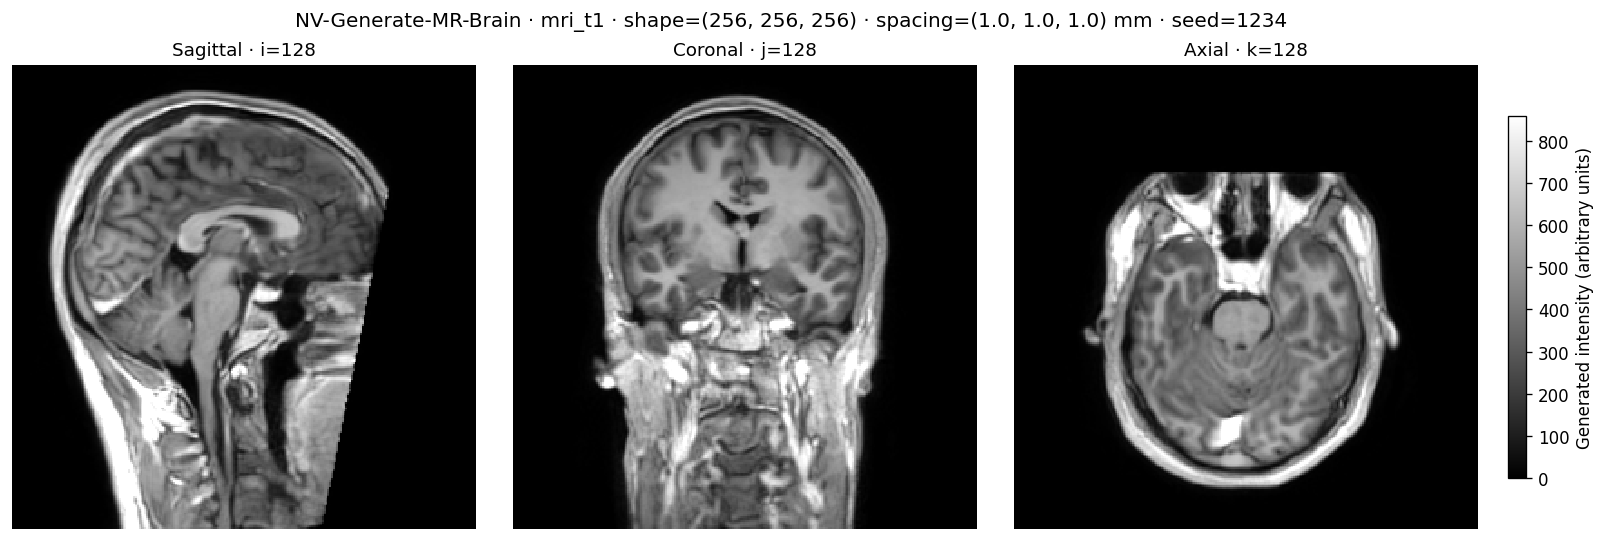

In [6]:
valid_values = volume_float[finite]
vmin, vmax = np.percentile(valid_values, (1, 99))
if not vmin < vmax:
    vmin, vmax = float(valid_values.min()), float(valid_values.max())
if not vmin < vmax:
    raise RuntimeError("输出没有可显示的强度范围")

centers = tuple(size // 2 for size in volume.shape)
planes = (
    (
        np.rot90(volume_float[centers[0], :, :]),
        f"Sagittal · i={centers[0]}",
        (0, volume.shape[1] * zooms[1], 0, volume.shape[2] * zooms[2]),
    ),
    (
        np.rot90(volume_float[:, centers[1], :]),
        f"Coronal · j={centers[1]}",
        (0, volume.shape[0] * zooms[0], 0, volume.shape[2] * zooms[2]),
    ),
    (
        np.rot90(volume_float[:, :, centers[2]]),
        f"Axial · k={centers[2]}",
        (0, volume.shape[0] * zooms[0], 0, volume.shape[1] * zooms[1]),
    ),
)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), constrained_layout=True)
image = None
for axis, (plane, title, extent) in zip(axes, planes):
    image = axis.imshow(
        plane,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal",
    )
    axis.set_title(title, fontsize=11)
    axis.axis("off")
fig.suptitle(
    f"NV-Generate-MR-Brain · {MODALITY} · shape={volume.shape} · "
    f"spacing={tuple(round(v, 3) for v in zooms)} mm · seed={RANDOM_SEED}",
    fontsize=12,
)
fig.colorbar(
    image,
    ax=axes,
    shrink=0.78,
    pad=0.02,
    label="Generated intensity (arbitrary units)",
)
plt.show()

---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.